In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

print("✅ Ready")

✅ Ready


#### Load hourly clean data

In [2]:
df_inr_h = pd.read_csv("../data/processed/USDINR_hourly_clean.csv",
                        index_col=0, parse_dates=True)
df_brl_h = pd.read_csv("../data/processed/USDBRL_hourly_clean.csv",
                        index_col=0, parse_dates=True)

df_inr_h.index.name = "datetime_utc"
df_brl_h.index.name = "datetime_utc"

# Detect close columns
def get_close(df):
    for col in df.columns:
        if "close" in col.lower():
            return col
    raise ValueError(f"No close col. Columns: {list(df.columns)}")

inr_col = get_close(df_inr_h)
brl_col = get_close(df_brl_h)

print(f"USD/INR hourly: {df_inr_h.shape} | close: '{inr_col}'")
print(f"USD/BRL hourly: {df_brl_h.shape} | close: '{brl_col}'")
print(f"INR range: {df_inr_h.index.min()} → {df_inr_h.index.max()}")
print(f"BRL range: {df_brl_h.index.min()} → {df_brl_h.index.max()}")

USD/INR hourly: (12147, 9) | close: 'close'
USD/BRL hourly: (12158, 9) | close: 'close'
INR range: 2024-03-05 01:00:00+00:00 → 2026-03-05 01:00:00+00:00
BRL range: 2024-03-05 01:00:00+00:00 → 2026-03-05 01:00:00+00:00


#### Derive hourly INR/BRL synthetic cross rate

In [3]:
# Same formula as daily: INR/BRL = USDINR / USDBRL
# Merge on datetime index — inner join to keep only aligned timestamps

df_inr_h = df_inr_h[[inr_col]].rename(columns={inr_col: "USDINR"})      # Renaming close value as USDINR and USDBRL
df_brl_h = df_brl_h[[brl_col]].rename(columns={brl_col: "USDBRL"})

cross_h = pd.merge(df_inr_h, df_brl_h,
                   left_index=True, right_index=True,         # Merging two close values 
                   how="inner")

cross_h["INRBRL"] = cross_h["USDINR"] / cross_h["USDBRL"]       # This tells How many INR equal 1 BRL

# Drop rows where cross rate is zero or NaN (bad ticks)
before = len(cross_h)
cross_h = cross_h[cross_h["INRBRL"] > 0].dropna(subset=["INRBRL"])
after   = len(cross_h)

print(f"Merged rows    : {before}")
print(f"After cleaning : {after}  (dropped {before - after} bad rows)")
print(f"Date range     : {cross_h.index.min()} → {cross_h.index.max()}")
print(f"\nSanity check — mean INR/BRL: {cross_h['INRBRL'].mean():.4f}")
print(cross_h.head(3))

Merged rows    : 11995
After cleaning : 11995  (dropped 0 bad rows)
Date range     : 2024-03-05 01:00:00+00:00 → 2026-03-05 01:00:00+00:00

Sanity check — mean INR/BRL: 15.6443
                              USDINR  USDBRL     INRBRL
datetime_utc                                           
2024-03-05 01:00:00+00:00  82.891998   4.945  16.762790
2024-03-05 02:00:00+00:00  82.903999   4.945  16.765217
2024-03-05 03:00:00+00:00  82.897003   4.945  16.763802


#### Price-based features (hourly-adapted)

In [4]:
feat_h = pd.DataFrame(index=cross_h.index)
price  = cross_h["INRBRL"]

# 1. Hourly return
feat_h["hourly_return"] = price.pct_change()   # tells you if the currency is rising or falling hour by hour

# 2. Log return — more stable, same reasoning as daily
feat_h["log_return"] = np.log(price / price.shift(1))   # Log is more stable, this is same as hournly_returns but weare loging it 

# 3. Rolling mean — 24h window instead of 7d
#    24 hours ≈ 1 full trading day across all sessions
feat_h["rolling_mean_24h"] = price.rolling(window=24, min_periods=12).mean()  # Average price over the past 24 hours, Helps detect whether the currency is trending up or down

# 4. Rolling std — 24h volatility window
feat_h["rolling_std_24h"] = price.rolling(window=24, min_periods=12).std()  # high std means the price is fluctuating a lot (to check volatility)

# 5. Momentum — 8-hour (roughly one trading session back)
feat_h["price_momentum_8h"] = (price - price.shift(8)) / price.shift(8) # Captures short-term momentum

print("Price features built:")
print(feat_h.tail(5).round(6))

Price features built:
                           hourly_return  log_return  rolling_mean_24h  \
datetime_utc                                                             
2026-03-04 21:00:00+00:00      -0.000289   -0.000289         17.549995   
2026-03-04 22:00:00+00:00       0.003126    0.003121         17.556986   
2026-03-04 23:00:00+00:00       0.000000    0.000000         17.563977   
2026-03-05 00:00:00+00:00      -0.002629   -0.002632         17.569232   
2026-03-05 01:00:00+00:00      -0.000521   -0.000521         17.573249   

                           rolling_std_24h  price_momentum_8h  
datetime_utc                                                   
2026-03-04 21:00:00+00:00         0.095084          -0.003667  
2026-03-04 22:00:00+00:00         0.096541          -0.001578  
2026-03-04 23:00:00+00:00         0.097455          -0.004008  
2026-03-05 00:00:00+00:00         0.096349          -0.003501  
2026-03-05 01:00:00+00:00         0.095540          -0.002452  


#### Hourly threshold calibration

In [5]:
# Daily threshold was 0.005 (0.5% move)
# Hourly moves are much smaller — need a lower threshold
# Let's find the right threshold empirically

returns_h = feat_h["hourly_return"].dropna()

print("=== HOURLY RETURN DISTRIBUTION ===")
print(f"  Mean : {returns_h.mean()*100:.4f}%")
print(f"  Std  : {returns_h.std()*100:.4f}%")
print(f"  Min  : {returns_h.min()*100:.4f}%")
print(f"  Max  : {returns_h.max()*100:.4f}%")

print("\n--- Threshold sensitivity ---")
for t in [0.0005, 0.001, 0.002, 0.003]:
    rate = (returns_h.abs() > t).mean() * 100
    note = "✅ good" if 15 <= rate <= 30 else ("⚠️ too many" if rate > 30 else "⚠️ too few")
    print(f"  threshold={t:.4f} ({t*100:.2f}%)  →  spike rate={rate:.1f}%  {note}")

=== HOURLY RETURN DISTRIBUTION ===
  Mean : 0.0006%
  Std  : 0.1843%
  Min  : -1.6928%
  Max  : 2.2125%

--- Threshold sensitivity ---
  threshold=0.0005 (0.05%)  →  spike rate=51.4%  ⚠️ too many
  threshold=0.0010 (0.10%)  →  spike rate=33.7%  ⚠️ too many
  threshold=0.0020 (0.20%)  →  spike rate=17.3%  ✅ good
  threshold=0.0030 (0.30%)  →  spike rate=9.0%  ⚠️ too few


#### Spike-based features (hourly)

In [13]:

# From Cell 5 output — pick the threshold giving 15-25% spike rate
HOURLY_THRESHOLD = 0.002   # 0.1% hourly move — update after seeing Cell 5 output

# 1. Spike signal
feat_h["spike_signal"] = (feat_h["hourly_return"].abs() > HOURLY_THRESHOLD).astype(int)

# 2. Spike intensity
feat_h["spike_intensity"] = np.where(
    feat_h["spike_signal"] == 1,
    feat_h["hourly_return"].abs(),
    0.0
)

# 3. Inter-spike interval (in hours) — vectorized
#    For every row: ISI = time elapsed since the most recent spike strictly before it.
#    At each spike row the "previous spike" is used (shift(1) on spike timestamps,
#    then ffill to propagate it forward to subsequent non-spike rows).
spike_times = feat_h.index[feat_h["spike_signal"] == 1]
last_spike_ts = (feat_h.index.to_series()
                           .where(feat_h["spike_signal"] == 1)  # NaT on non-spike rows
                           .shift(1)                             # at each spike → its predecessor
                           .ffill())                             # carry forward to non-spike rows
isi_h = (feat_h.index.to_series() - last_spike_ts).dt.total_seconds() / 3600
feat_h["inter_spike_interval_h"] = isi_h

spike_rate = feat_h["spike_signal"].mean() * 100
print(f"Hourly spike rate : {spike_rate:.1f}%  (threshold={HOURLY_THRESHOLD})")
print(f"Mean ISI (hours)  : {feat_h['inter_spike_interval_h'].mean():.1f}h")
print(f"Max  ISI (hours)  : {feat_h['inter_spike_interval_h'].max():.1f}h")


Hourly spike rate : 17.3%  (threshold=0.002)
Mean ISI (hours)  : 12.0h
Max  ISI (hours)  : 118.0h


#### Time-of-day feature (hourly specific)

In [7]:
# Extract hour of day in UTC (0–23)
# This captures FX session patterns:
#   00–08 UTC → Asian session  (Tokyo, Singapore, Mumbai)
#   07–16 UTC → European session (London)
#   13–21 UTC → US session (New York)
#   08–09 UTC → Asia/Europe overlap — often highest volatility for INR
#   13–16 UTC → Europe/US overlap  — often highest liquidity globally

feat_h["hour_of_day"] = feat_h.index.hour

# Session label (useful for analysis, won't be a model input directly)
def get_session(hour):
    if 0  <= hour < 7 : return "Asian"
    if 7  <= hour < 13: return "European"
    if 13 <= hour < 20: return "US"
    return "Off-hours"

feat_h["session"] = feat_h["hour_of_day"].apply(get_session)

# Spike rate by session — validates the feature is meaningful
print("=== SPIKE RATE BY TRADING SESSION ===")
session_stats = feat_h.groupby("session")["spike_signal"].agg(["mean","count"])
session_stats["spike_pct"] = (session_stats["mean"] * 100).round(2)
print(session_stats[["count","spike_pct"]].sort_values("spike_pct", ascending=False))
print("\nHigher spike rate in certain sessions = hour_of_day is a useful feature ✅")

# Drop the string session column — keep only numeric hour_of_day
feat_h = feat_h.drop(columns=["session"])

=== SPIKE RATE BY TRADING SESSION ===
           count  spike_pct
session                    
US          3604      26.61
European    3096      21.71
Off-hours   1852       9.45
Asian       3443       7.67

Higher spike rate in certain sessions = hour_of_day is a useful feature ✅


### Target variable (hourly)

In [9]:
# Same logic as daily: will next hour's price be higher?
feat_h["target"] = (price.shift(-1) > price).astype(int)

n_up   = feat_h["target"].sum()
n_down = (feat_h["target"] == 0).sum()
print(f"Hourly target distribution:")
print(f"  Up   (1): {n_up}  ({100*n_up/len(feat_h):.1f}%)")
print(f"  Down (0): {n_down} ({100*n_down/len(feat_h):.1f}%)")

Hourly target distribution:
  Up   (1): 5692  (47.5%)
  Down (0): 6303 (52.5%)


#### Save hourly feature matrix

In [10]:
# Drop raw price columns — not model inputs
cols_to_drop = [c for c in ["USDINR", "USDBRL", "INRBRL"] if c in feat_h.columns]
feat_h_save  = feat_h.drop(columns=cols_to_drop)

# Drop last row (NaN target — no next hour)
feat_h_save = feat_h_save.dropna(subset=["target"])

save_path = "../data/processed/feature_matrix_hourly.csv"
os.makedirs("../data/processed", exist_ok=True)
feat_h_save.to_csv(save_path)

print(f"✅ Saved: {save_path}")
print(f"   Shape : {feat_h_save.shape}")
print(f"\nColumns:")
for col in feat_h_save.columns:
    role = "TARGET ⭐" if col == "target" else "feature"
    nulls = feat_h_save[col].isna().sum()
    print(f"  {col:<28} [{role}]  nulls={nulls}")

✅ Saved: ../data/processed/feature_matrix_hourly.csv
   Shape : (11995, 10)

Columns:
  hourly_return                [feature]  nulls=1
  log_return                   [feature]  nulls=1
  rolling_mean_24h             [feature]  nulls=11
  rolling_std_24h              [feature]  nulls=11
  price_momentum_8h            [feature]  nulls=8
  spike_signal                 [feature]  nulls=0
  spike_intensity              [feature]  nulls=0
  inter_spike_interval_h       [feature]  nulls=15
  hour_of_day                  [feature]  nulls=0
  target                       [TARGET ⭐]  nulls=0


#### Daily vs hourly spike comparison

In [11]:
# Load daily feature matrix for comparison
feat_d = pd.read_csv("../data/processed/feature_matrix_daily.csv",
                     index_col=0, parse_dates=True)
feat_d.index.name = "date"

daily_spike_rate  = feat_d["spike_signal"].mean() * 100
hourly_spike_rate = feat_h_save["spike_signal"].mean() * 100

daily_total  = feat_d["spike_signal"].sum()
hourly_total = feat_h_save["spike_signal"].sum()

print("=" * 62)
print("DAILY vs HOURLY SPIKE COMPARISON")
print("=" * 62)
print(f"{'Metric':<30} {'Daily':>12} {'Hourly':>14}")
print("-" * 62)
print(f"{'Threshold':<30} {'0.5%':>12} {f'{HOURLY_THRESHOLD*100:.1f}%':>14}")
print(f"{'Total rows':<30} {len(feat_d):>12} {len(feat_h_save):>14}")
print(f"{'Total spike events':<30} {int(daily_total):>12} {int(hourly_total):>14}")
print(f"{'Spike rate':<30} {daily_spike_rate:>11.1f}% {hourly_spike_rate:>13.1f}%")
print(f"{'Mean ISI':<30} {'days':>12} {'hours':>14}")
print(f"  Daily  mean ISI : {feat_d['inter_spike_interval'].mean():.1f} days")
print(f"  Hourly mean ISI : {feat_h_save['inter_spike_interval_h'].mean():.1f} hours")
print("=" * 62)

# Consistency check: do hourly spikes cluster around same dates as daily?
# Convert hourly spike timestamps to dates and compare
hourly_spike_dates = set(
    feat_h_save[feat_h_save["spike_signal"] == 1].index.normalize().date
)
daily_spike_dates  = set(
    feat_d[feat_d["spike_signal"] == 1].index.date
)

# Overlap within the same date range
common_start = max(feat_d.index.min(), feat_h_save.index.min().tz_localize(None)
                   if feat_h_save.index.tz else feat_h_save.index.min())
common_end   = min(feat_d.index.max(), feat_h_save.index.max().tz_localize(None)
                   if feat_h_save.index.tz else feat_h_save.index.max())

daily_in_range  = {d for d in daily_spike_dates  if common_start.date() <= d <= common_end.date()}
hourly_in_range = {d for d in hourly_spike_dates if common_start.date() <= d <= common_end.date()}

overlap     = daily_in_range & hourly_in_range
consistency = len(overlap) / len(daily_in_range) * 100 if daily_in_range else 0

print(f"\nConsistency check (overlapping date range):")
print(f"  Daily spike days in range  : {len(daily_in_range)}")
print(f"  Hourly spike days in range : {len(hourly_in_range)}")
print(f"  Days with spike in BOTH    : {len(overlap)}")
print(f"  Consistency rate           : {consistency:.1f}%")
print(f"\n  {'✅ Spike patterns are consistent across scales' if consistency > 50 else '⚠️  Low consistency — check thresholds'}")

DAILY vs HOURLY SPIKE COMPARISON
Metric                                Daily         Hourly
--------------------------------------------------------------
Threshold                              0.5%           0.2%
Total rows                             1823          11995
Total spike events                      101           2070
Spike rate                             5.5%          17.3%
Mean ISI                               days          hours
  Daily  mean ISI : 36.4 days
  Hourly mean ISI : 12.0 hours

Consistency check (overlapping date range):
  Daily spike days in range  : 30
  Hourly spike days in range : 499
  Days with spike in BOTH    : 29
  Consistency rate           : 96.7%

  ✅ Spike patterns are consistent across scales


#### Visualize hourly spike train (last 2 weeks)

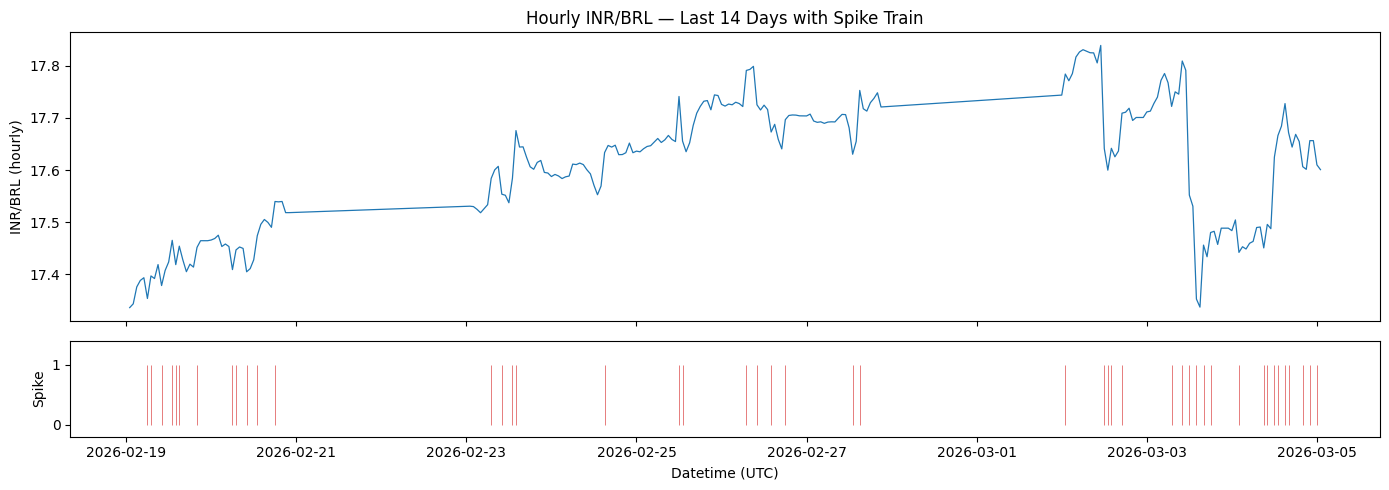

✅ Saved: outputs/plot_hourly_spike_train.png


In [12]:
# Show last 14 days of hourly data — makes it feel "live"
two_weeks_ago = feat_h_save.index.max() - pd.Timedelta(days=14)
recent = feat_h_save[feat_h_save.index >= two_weeks_ago]

fig, axes = plt.subplots(2, 1, figsize=(14, 5),
                          gridspec_kw={"height_ratios": [3, 1]},
                          sharex=True)

# Top: price
price_recent = cross_h["INRBRL"].reindex(recent.index)
axes[0].plot(price_recent.index, price_recent.values,
             color="#1f77b4", linewidth=0.9)
axes[0].set_ylabel("INR/BRL (hourly)")
axes[0].set_title("Hourly INR/BRL — Last 14 Days with Spike Train")

# Bottom: spike train
spike_idx = recent[recent["spike_signal"] == 1].index
axes[1].vlines(spike_idx, ymin=0, ymax=1,
               color="#d62728", linewidth=0.6, alpha=0.7)
axes[1].set_ylim(-0.2, 1.4)
axes[1].set_yticks([0, 1])
axes[1].set_ylabel("Spike")
axes[1].set_xlabel("Datetime (UTC)")

plt.tight_layout()
plt.savefig("../outputs/plot_hourly_spike_train.png", bbox_inches="tight")
plt.show()
print("✅ Saved: outputs/plot_hourly_spike_train.png")
